<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    103886 non-null  str    
 1   customer_unique_id             103886 non-null  str    
 2   customer_zip_code_prefix       103886 non-null  int64  
 3   customer_city                  103886 non-null  str    
 4   customer_state                 103886 non-null  str    
 5   order_id                       103886 non-null  str    
 6   order_status                   103886 non-null  str    
 7   order_purchase_timestamp       103886 non-null  str    
 8   order_approved_at              103711 non-null  str    
 9   order_delivered_carrier_date   101998 non-null  str    
 10  order_delivered_customer_date  100754 non-null  str    
 11  order_estimated_delivery_date  103886 non-null  str    
 12  payment_sequential             103886 non

C:\Users\user\AppData\Local\Temp\ipykernel_8172\3483487528.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


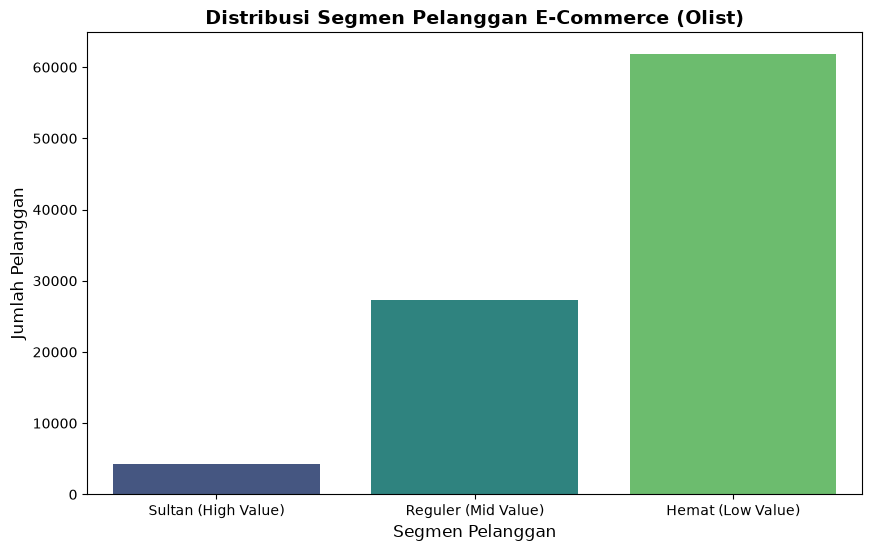

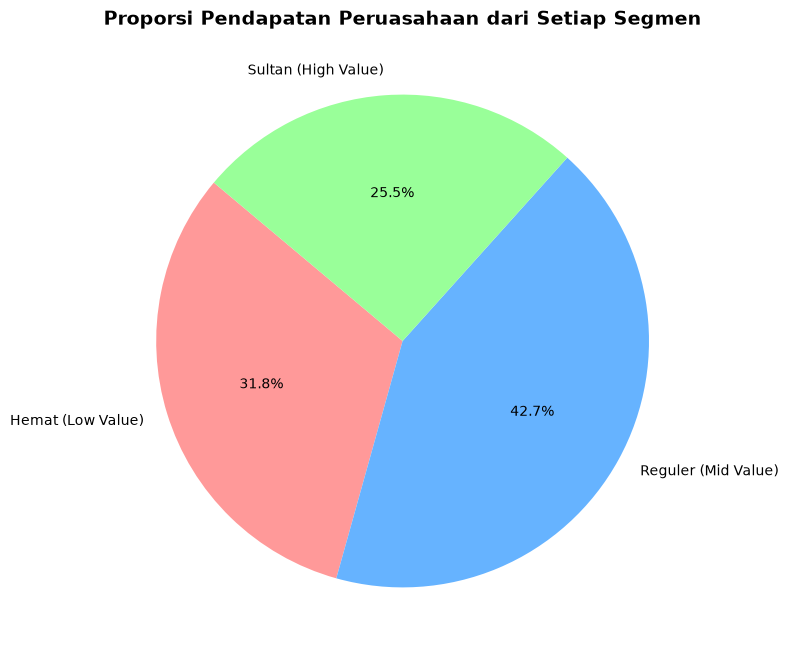

In [ ]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

df_customers = pd.read_csv('olist_customers_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')

df_gabung_1 = pd.merge (df_customers, df_orders, on='customer_id')
df_final = pd.merge(df_gabung_1, df_payments, on='order_id')
df_final.head()

df_final.info()
df_final.isnull().sum()

df_clean = df_final.dropna()
print("Jumlah data sebelum dibersihkan:", len(df_final))
print("Jumlah data setelah dibersihkan:", len(df_clean))

df_customer_spend = df_clean.groupby('customer_unique_id')['payment_value'].sum().reset_index()
df_customer_spend.columns = ['ID_Pelanggan', 'Total_Belanja']
df_top_customers = df_customer_spend.sort_values(by='Total_Belanja', ascending=False)
df_top_customers.head(10)

def tentukan_segmen(total_uang):
    if total_uang >= 500:
        return 'Sultan (High Value)'
    elif total_uang >= 150:
        return 'Reguler (Mid Value)'
    else:
        return 'Hemat (Low Value)'

df_customer_spend['Segmen'] = df_customer_spend['Total_Belanja'].apply(tentukan_segmen)

print("Ringkasan Jumlah Pelanggan per Segmen:")
print(df_customer_spend['Segmen'].value_counts())
print("-" * 30)

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_customer_spend,
    x= 'Segmen',
    order=['Sultan (High Value)', 'Reguler (Mid Value)', 'Hemat (Low Value)'],
    palette ='viridis'
)

plt.title('Distribusi Segmen Pelanggan E-Commerce (Olist)', fontsize=14, fontweight='bold')                                 
plt.xlabel('Segmen Pelanggan', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)

plt.show

df_revenue = df_customer_spend.groupby('Segmen')['Total_Belanja'].sum().reset_index()
plt.figure(figsize=(8,8))
plt.pie(
    df_revenue['Total_Belanja'],
    labels= df_revenue['Segmen'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999','#66b3ff','#99ff99']
)

plt.title('Proporsi Pendapatan Peruasahaan dari Setiap Segmen', fontsize=14, fontweight='bold')

plt.show()


 Kesimpulan Utama (Key Insights) Dari hasil eksplorasi dan segmentasi data pelanggan Olist E-Commerce, ada temuan perilaku konsumen yang sangat menarik:

Ilusi Kuantitas vs Omzet: Secara jumlah kepala,
pelanggan di segmen Hemat (Low Value) sangat mendominasi pasar dengan total lebih dari 60.000 orang. Namun, tulang punggung pendapatan perusahaan justru dipegang oleh segmen Reguler (Mid Value) yang menyumbang porsi omzet terbesar, yaitu 42,7%.

Kekuatan Daya Beli Segmen VIP: Kelompok pelanggan Sultan (High Value) ukurannya paling kecil (kurang dari 5.000 orang). Meski begitu, mereka memiliki daya beli yang sangat kuat dan mampu menyumbang lebih dari seperempat total pendapatan perusahaan (25,5%).

Rekomendasi Strategi (Actionable Items)
Karena setiap segmen punya karakteristik belanja yang berbeda, strategi marketing tidak bisa disamaratakan. Berikut rekomendasi untuk tim bisnis:

Untuk Segmen Reguler (Fokus: Retensi & Peningkatan Belanja):
Sebagai penyumbang omzet terbesar, prioritas utama adalah menjaga mereka tetap berbelanja di platform kita. Tawarkan program loyalty point atau algoritma rekomendasi produk pelengkap (cross-selling) saat mereka berada di halaman checkout.

Untuk Segmen Hemat (Fokus: Volume & Up-Selling):
Target utamanya adalah "memaksa" mereka membelanjakan uang sedikit lebih banyak di setiap transaksi. Terapkan strategi bundling produk (misal: "Beli 2 Diskon 15%") atau berikan kupon gratis ongkir dengan syarat minimal belanja (di atas rata-rata pengeluaran mereka saat ini) agar perlahan mereka naik kelas ke segmen Reguler.

Untuk Segmen Sultan (Fokus: Eksklusivitas):
Kehilangan satu pelanggan di segmen ini sama dampaknya dengan kehilangan puluhan pelanggan Hemat. Berikan pengalaman VIP yang personal, seperti Customer Service tanpa antre, akses eksklusif untuk peluncuran produk baru, atau kurasi produk premium bulanan.